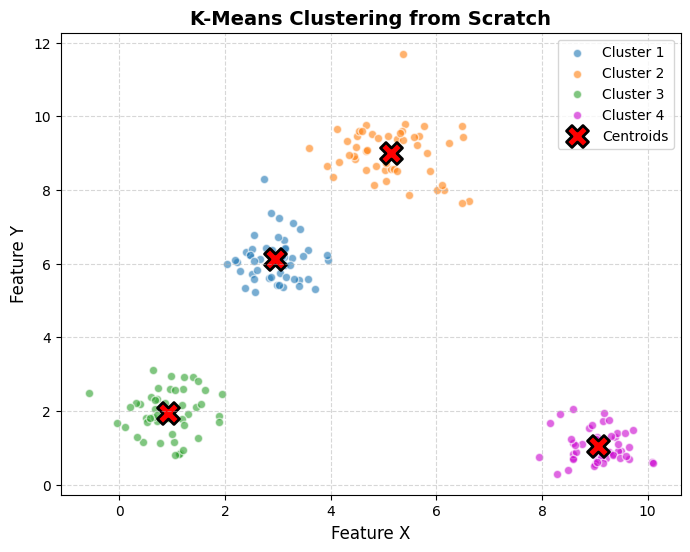

In [31]:
#Q. Implement the following machine learning algorithms from scratch using Python:
#a) K-Means Clustering:
#Implement the K-Means clustering algorithm without using the built-in KMeans function. The implementation must include centroid initialization, 
#distance calculation, cluster assignment, centroid updating, and iteration until convergence.

import numpy as np
import matplotlib.pyplot as plt

class KMeansFromScratch:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        
    def fit(self, X):
        # 1. Centroid Initialization
        n_samples, n_features = X.shape
        random_indices = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_indices]
        
        for i in range(self.max_iters):
            # 2. Distance Calculation & Cluster Assignment
            distances = self._calculate_distances(X)
            labels = np.argmin(distances, axis=1)
            
            # 3. Centroid Updating
            new_centroids = np.zeros((self.k, n_features))
            for cluster_idx in range(self.k):
                cluster_points = X[labels == cluster_idx]
                
                if len(cluster_points) > 0:
                    new_centroids[cluster_idx] = np.mean(cluster_points, axis=0)
                else:
                    new_centroids[cluster_idx] = X[np.random.choice(n_samples)]
            
            # 4. Iteration Until Convergence
            centroid_shifts = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            
            if centroid_shifts < self.tol:
                break
                
        return labels

    def _calculate_distances(self, X):
        return np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)


# Example Usage & Plotting:
if __name__ == "__main__":
    # Create a synthetic dataset (3 clear clusters)
    np.random.seed(42)
    cluster1 = np.random.normal(loc=[1.0, 2.0], scale=0.6, size=(50, 2))
    cluster2 = np.random.normal(loc=[3.0, 6.0], scale=0.5, size=(50, 2))
    cluster3 = np.random.normal(loc=[5.0, 9.0], scale=0.7, size=(50, 2))
    cluster4 = np.random.normal(loc=[9.0, 1.0], scale=0.5, size=(50, 2))
    X = np.vstack([cluster1, cluster2, cluster3,cluster4])
    
    # Run the custom KMeans implementation
    kmeans = KMeansFromScratch(k=4, max_iters=100)
    assigned_labels = kmeans.fit(X)
    
    # --- Plotting the Results ---
    plt.figure(figsize=(8, 6))
    
    # Map colors to each unique cluster cluster
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#ca02cf']
    
    # 1. Scatter plot data points, color-coded by assigned cluster label
    for cluster_idx in range(kmeans.k):
        cluster_points = X[assigned_labels == cluster_idx]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                    color=colors[cluster_idx], alpha=0.6, 
                    edgecolors='w', label=f'Cluster {cluster_idx + 1}')
        
    # 2. Plot final learned centroids as distinct large 'X' markers
    plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], 
                color='red', marker='X', s=250, 
                edgecolors='black', linewidths=2, label='Centroids')
    
    plt.title('K-Means Clustering from Scratch', fontsize=14, fontweight='bold')
    plt.xlabel('Feature X', fontsize=12)
    plt.ylabel('Feature Y', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


In [ ]:
#b) Linear Discriminant Analysis (LDA):
#Implement LDA without using the built-in LDA function. Compute the within-class scatter matrix, between-class scatter matrix, eigenvalues/eigenvectors, 
#and project the data onto the selected discriminant components.


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

class LDADay08:
    def __init__(self, n_components):
        self.n_components = n_components
        self.linear_discriminants = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        class_labels = np.unique(y)

        # 1. Compute overall mean and class-wise means
        mean_overall = np.mean(X, axis=0)
        SW = np.zeros((n_features, n_features))
        SB = np.zeros((n_features, n_features))

        for c in class_labels:
            X_c = X[y == c]
            mean_c = np.mean(X_c, axis=0)

             #1: Fully Vectorized SW Matrix ---
            X_centered = X_c - mean_c
            SW += X_centered.T @ X_centered

            # 2: Clean Array Broadcasting for SB ---
            n_c = X_c.shape[0]
            mean_diff = (mean_c - mean_overall).reshape(-1, 1)
            SB += n_c * (mean_diff @ mean_diff.T)

        # 3. Solve the generalized eigenvalue problem
        # Adding a tiny regularization term to the diagonal avoids numerical instability
        SW += np.eye(n_features) * 1e-6
        A = np.linalg.inv(SW) @ SB
        
        eigenvalues, eigenvectors = np.linalg.eig(A)
        eigenvectors = eigenvectors.T
        
        # 4. Sort eigenvalues and eigenvectors in descending order
        sorted_indices = np.argsort(np.abs(eigenvalues))[::-1]
        
        # 5. Select the top k discriminant vectors
        self.linear_discriminants = eigenvectors[sorted_indices[:self.n_components]]

    def transform(self, X):
        # 6. Project the given dataset onto the new lower-dimensional subspace
        return np.real(X @ self.linear_discriminants.T)


# 7. Load Wine dataset and visualize the transformed data
if __name__ == "__main__":
    wine = load_wine()
    X = wine.data
    y = wine.target
    target_names = wine.target_names

    # Use the optimized class
    lda = LDADay08(n_components=2)
    lda.fit(X, y)
    X_projected = lda.transform(X)

    # Plotting code
    plt.figure(figsize=(8, 6))
    colors = ['#FF0000', '#00FF00', '#0000FF']
    
    for i, color, target_name in zip(range(3), colors, target_names):
        plt.scatter(
            X_projected[y == i, 0],
            X_projected[y == i, 1],
            color=color,
            alpha=0.8,
            edgecolors='k',
            label=target_name
        )
        
    plt.xlabel("Linear Discriminant 1")
    plt.ylabel("Linear Discriminant 2")
    plt.title("Linear Discriminant Analysis (Wine Dataset)")
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()